<a href="https://colab.research.google.com/github/x1001000/Colab-Notebooks/blob/main/%E5%A4%9A%E6%A8%A1%E6%85%8B%E6%A8%A1%E5%9E%8B%E7%9C%BE%E6%95%B8%E6%9A%B4%E5%8A%9B%E8%A7%A3%E6%AF%94%E5%B0%8D%E8%B3%87%E6%96%99%E6%88%96%E7%88%AC%E5%8F%96%E8%B3%87%E6%96%99%E5%95%8F%E9%A1%8C.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 圖像提示詞（[此網頁](https://libguides.brooklyn.cuny.edu/Bloomberg/Excel)最下方的截圖為例）

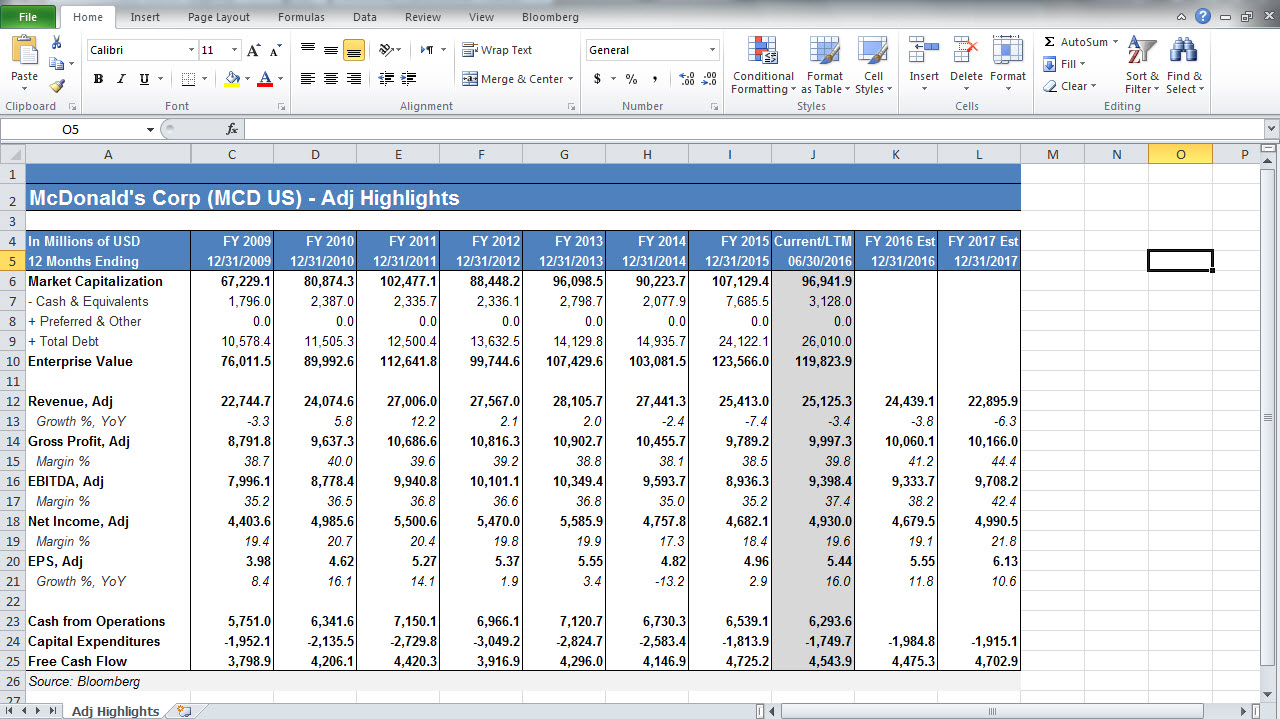

In [ ]:
import requests
r = requests.get('https://s3.amazonaws.com/libapps/accounts/38150/images/2016-10-04_Excel.jpg')

import base64
image_prompt = base64.b64encode(r.content).decode('utf-8')

from PIL import Image
from io import BytesIO
Image.open(BytesIO(r.content))

# 文字提示詞

In [ ]:
text_prompt = 'Output dataframe. Row 5 as the header.'

# 多模態模型（用 gemini-2.5-flash 才可設定不思考）

In [ ]:
model = "gemini-2.5-flash"

# 輸入圖像加文字、不思考較快較省、輸出JSON字串

In [ ]:
import os
from google import genai
from google.genai import types
from google.colab import userdata
os.environ["GEMINI_API_KEY"] = userdata.get("GEMINI_API_KEY")
client = genai.Client(api_key=os.environ.get("GEMINI_API_KEY"))

contents = [
    types.Content(
        role="user",
        parts=[
            types.Part.from_bytes(data=image_prompt, mime_type="image/jpeg"),
            types.Part.from_text(text=text_prompt),
        ],
    ),
]

config = types.GenerateContentConfig(
    thinking_config = types.ThinkingConfig(thinking_budget=0),
    response_mime_type="application/json",
)

def generate():
    return client.models.generate_content(
        model=model,
        contents=contents,
        config=config,
    )

# 跑 10 次生成，間隔 5 秒降低快取機率

In [ ]:
N = 10

import time
import pandas as pd
import json

dfs = []
for _ in range(N):
    time.sleep(5)
    response = generate()
    try:
        df = pd.DataFrame(json.loads(response.text))
        dfs.append(df)
        print(df.shape)
    except:
        # print(response.text)
        pass

(18, 11)
(18, 11)
(19, 11)
(18, 11)
(19, 11)
(18, 11)
(18, 1)
(18, 11)
(19, 11)
(18, 11)


In [ ]:
from collections import Counter

shapes = [df.shape for df in dfs]
shape_counts = Counter(shapes)
mode_shape = shape_counts.most_common(1)[0][0]
mode_count = shape_counts.most_common(1)[0][1]

print(f"數據框形狀的眾數是 {mode_shape}")
print(f"數據框形狀為眾數的個數是 {mode_count}")

數據框形狀的眾數是 (18, 11)
數據框形狀為眾數的個數是 6


In [ ]:
# Get the shape of the dataframes
num_rows, num_cols = mode_shape

# Initialize a list to store rows of the final dataframe
mode_value_rows = []
mode_count_rows = []

# Iterate through rows and columns
for r in range(num_rows):
    mode_value_row = []
    mode_count_row = []
    for c in range(num_cols):
        # Get values at the current cell position from all dataframes
        mode_shape_dfs = [df for df in dfs if df.shape == mode_shape]
        cell_values = [df.iloc[r, c] for df in mode_shape_dfs]
        value_counts = Counter(cell_values)
        mode_value = value_counts.most_common(1)[0][0]
        mode_count = value_counts.most_common(1)[0][1]

        mode_value_row.append(mode_value)
        mode_count_row.append(mode_count)
    mode_value_rows.append(mode_value_row)
    mode_count_rows.append(mode_count_row)

# Create the final dataframe with mode values
mode_value_df = pd.DataFrame(mode_value_rows, columns=mode_shape_dfs[0].columns)
mode_count_df = pd.DataFrame(mode_count_rows, columns=mode_shape_dfs[0].columns)

# Display the final dataframe
display(mode_value_df)
display(mode_count_df)

,12 Months Ending,FY 2009\n12/31/2009,FY 2010\n12/31/2010,FY 2011\n12/31/2011,FY 2012\n12/31/2012,FY 2013\n12/31/2013,FY 2014\n12/31/2014,FY 2015\n12/31/2015,Current/LTM\n06/30/2016,FY 2016 Est\n12/31/2016,FY 2017 Est\n12/31/2017
0,Market Capitalization,67229.10,80874.30,102477.10,88448.20,96098.50,90223.70,107129.40,96941.90,NaN,NaN
1,+ Cash & Equivalents,1796.00,2387.00,2335.70,2336.10,2798.70,2077.90,7685.50,3128.00,NaN,NaN
2,+ Preferred & Other,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,NaN,NaN
3,+ Total Debt,10578.40,11505.30,12500.40,13632.50,14129.80,14935.70,24122.10,26010.00,NaN,NaN
4,Enterprise Value,76011.50,89992.60,112641.80,99744.60,107429.60,103081.50,123566.00,119823.90,NaN,NaN
5,"Revenue, Adj",22744.70,24074.60,27006.00,27567.00,28105.70,27441.30,25413.00,25125.30,24439.10,22895.90
6,"Growth %, YoY",-3.30,5.80,12.20,2.10,2.00,-2.40,-7.40,-3.40,-3.80,-6.30
7,"Gross Profit, Adj",8791.80,9637.30,10686.60,10816.30,10902.70,10455.70,9789.20,9997.30,10060.10,10166.00
8,Margin %,38.70,40.00,39.60,39.20,38.80,38.10,38.50,39.80,41.20,44.40
9,"EBITDA, Adj",7996.10,8778.40,9940.80,10101.10,10349.40,9593.70,8936.30,9398.40,9333.70,9708.20


,12 Months Ending,FY 2009\n12/31/2009,FY 2010\n12/31/2010,FY 2011\n12/31/2011,FY 2012\n12/31/2012,FY 2013\n12/31/2013,FY 2014\n12/31/2014,FY 2015\n12/31/2015,Current/LTM\n06/30/2016,FY 2016 Est\n12/31/2016,FY 2017 Est\n12/31/2017
0,6,5,5,5,5,5,5,5,5,1,1
1,5,5,5,5,5,5,5,5,5,1,1
2,6,5,5,5,5,5,5,5,5,1,1
3,6,5,5,5,5,5,5,5,5,1,1
4,6,5,5,5,5,5,5,5,5,1,1
5,6,5,5,5,5,5,5,5,5,5,5
6,6,5,5,5,5,5,5,5,5,5,5
7,6,5,5,5,5,5,5,5,5,5,5
8,6,5,5,5,5,5,5,5,5,5,5
9,6,5,5,5,5,5,5,5,5,5,5


# 說明
1. 因為 NaN 不等於 NaN，所以 NaN 的眾數的個數是 1
2. 因為某次生成了千位分隔號，如下所示，所以眾數的個數剩 5
3. 眾數應該都是對的

In [ ]:
mode_shape_dfs[3]

,12 Months Ending,FY 2009\n12/31/2009,FY 2010\n12/31/2010,FY 2011\n12/31/2011,FY 2012\n12/31/2012,FY 2013\n12/31/2013,FY 2014\n12/31/2014,FY 2015\n12/31/2015,Current/LTM\n06/30/2016,FY 2016 Est\n12/31/2016,FY 2017 Est\n12/31/2017
0,Market Capitalization,"67,229.1","80,874.3","102,477.1","88,448.2","96,098.5","90,223.7","107,129.4","96,941.9",None,None
1,+ Cash & Equivalents,"1,796.0","2,387.0","2,335.7","2,336.1","2,798.7","2,077.9","7,685.5","3,128.0",None,None
2,+ Preferred & Other,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,None,None
3,+ Total Debt,"10,578.4","11,505.3","12,500.4","13,632.5","14,129.8","14,935.7","24,122.1","26,010.0",None,None
4,Enterprise Value,"76,011.5","89,992.6","112,641.8","99,744.6","107,429.6","103,081.5","123,566.0","119,823.9",None,None
5,"Revenue, Adj","22,744.7","24,074.6","27,006.0","27,567.0","28,105.7","27,441.3","25,413.0","25,125.3","24,439.1","22,895.9"
6,"Growth %, YoY",-3.3,5.8,12.2,2.1,2.0,-2.4,-7.4,-3.4,-3.8,-6.3
7,"Gross Profit, Adj","8,791.8","9,637.3","10,686.6","10,816.3","10,902.7","10,455.7","9,789.2","9,997.3","10,060.1","10,166.0"
8,Margin %,38.7,40.0,39.6,39.2,38.8,38.1,38.5,39.8,41.2,44.4
9,"EBITDA, Adj","7,996.1","8,778.4","9,940.8","10,101.1","10,349.4","9,593.7","8,936.3","9,398.4","9,333.7","9,708.2"


# API 費用

In [ ]:
PRICING = {
    'gemini-2.5-flash': {'input': 0.3, 'output': 2.5, 'thinking': 2.5, 'caching': 0.075},
    'gemini-2.5-pro': {'input': 1.25, 'output': 10, 'thinking': 10, 'caching': 0.31},
}

In [ ]:
usage_metadata = response.usage_metadata
cost = (
    usage_metadata.prompt_token_count * PRICING[model]['input'] +
    usage_metadata.candidates_token_count * PRICING[model]['output'] +
    (usage_metadata.cached_content_token_count or 0) * PRICING[model]['caching'] +
    (usage_metadata.thoughts_token_count or 0) * PRICING[model]['thinking']
    ) / 1e6
print(f'跑 {N} 次生成，費用約等於 {N * cost:.3f} USD')

跑 10 次生成，費用約等於 0.140 USD
